# Exercise 4: Autoregressive Image Modeling
## Submission date: 25\05\2026, 23:59.

Submitted by:

## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
# from IPython.display import set_matplotlib_formats
# %config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [2]:
# Convert images from 0-1 to 0-255 (integers).
def discretize(sample):
    return (sample * 255).to(torch.long)

# Transformations applied on each image => only make them a tensor
transform = transforms.Compose([transforms.ToTensor(), discretize])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

#pl.seed_everything(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


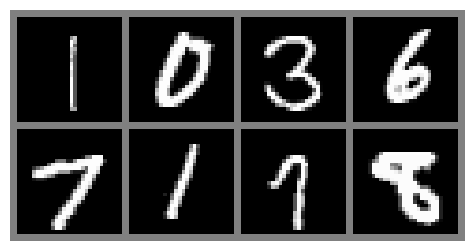

In [3]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=255)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

## Define Masked Convolutions

In [4]:
class MaskedConvolution(nn.Module):

    def __init__(self, c_in, c_out, mask, **kwargs):
        """
        Implements a convolution with mask applied on its weights.
        Inputs:
            c_in - Number of input channels
            c_out - Number of output channels
            mask - Tensor of shape [kernel_size_H, kernel_size_W] with 0s where
                   the convolution should be masked, and 1s otherwise.
            kwargs - Additional arguments for the convolution
        """
        super().__init__()
        # For simplicity: calculate padding automatically
        kernel_size = (mask.shape[0], mask.shape[1])

        # Actual convolution
        self.conv = nn.Conv2d(c_in, c_out, kernel_size, padding='same', **kwargs)

        # Mask as buffer => it is no parameter but still a tensor of the module
        # (must be moved with the devices)
        self.register_buffer('mask', mask[None,None].to(device))

    def forward(self, x):
        self.conv.weight.data *= self.mask # Ensures zero's at masked positions
        return self.conv(x)

In [5]:
class VerticalStackConvolution(MaskedConvolution):

    def __init__(self, c_in, c_out, kernel_size=3, mask_center=False, **kwargs):
        # Mask out all pixels below. For efficiency, we could also reduce the kernel
        # size in height, but for simplicity, we stick with masking here.
        mask = torch.ones(kernel_size, kernel_size)
        mask[kernel_size//2+1:,:] = 0

        # For the very first convolution, we will also mask the center row
        if mask_center:
            mask[kernel_size//2,:] = 0

        super().__init__(c_in, c_out, mask, **kwargs)

class HorizontalStackConvolution(MaskedConvolution):

    def __init__(self, c_in, c_out, kernel_size=3, mask_center=False, **kwargs):
        # Mask out all pixels on the left. Note that our kernel has a size of 1
        # in height because we only look at the pixel in the same row.
        mask = torch.ones(1,kernel_size)
        mask[0,kernel_size//2+1:] = 0

        # For the very first convolution, we will also mask the center pixel
        if mask_center:
            mask[0,kernel_size//2] = 0

        super().__init__(c_in, c_out, mask, **kwargs)

## PixelCNN without Gating and dilations

Instead of the GatedMaskConv from the tutorial, we defined a MaskedConvLayer for the model.

In [6]:
class MaskedConvLayer(nn.Module):
        def __init__(self, c_in, kernel_size=3, **kwargs):
            """
            Non Gated Convolution block implemented
            """
            super().__init__()
            self.kernel_size = kernel_size
            self.v_stack = VerticalStackConvolution(
                 c_in = c_in,
                 c_out = c_in,
                 kernel_size = self.kernel_size,
                 **kwargs
            )
            self.h_stack = HorizontalStackConvolution(
                 c_in = c_in,
                 c_out = c_in,
                 kernel_size = self.kernel_size,
                 **kwargs
            )

        def forward(self, v_stack, h_stack):
          v_stack_out = self.v_stack(v_stack)

          h_stack_out = self.h_stack(h_stack)
          h_stack_out = h_stack_out + v_stack_out

          v_stack_out = F.elu(v_stack_out)
          h_stack_out = F.elu(h_stack_out)
          
          return v_stack_out, h_stack_out

In [7]:
class PixelCNN(nn.Module):

    def __init__(self, c_in, c_hidden, kernel_size=3, num_layers=5):
        super().__init__()

        self.kernel_size = kernel_size
        # First stacks/layers
        self.conv_vstack = VerticalStackConvolution(
                 c_in = c_in,
                 c_out = c_hidden,
                 kernel_size = self.kernel_size,
                 mask_center = True
            )
        self.conv_hstack = HorizontalStackConvolution(
                 c_in = c_in,
                 c_out = c_hidden,
                 kernel_size = self.kernel_size,
                 mask_center = True
            )
        
        # Rest of the layers, no mask
        self.conv_layers = nn.ModuleList(
            [MaskedConvLayer(c_in = c_hidden, kernel_size=self.kernel_size) for _ in range(num_layers)]
            )
        
        self.conv_out = nn.Conv2d(c_hidden, c_in * 256, kernel_size=1)
        

    def forward(self, x):
        """
        Forward image through model and return logits for each pixel.
        Inputs:
            x - Image tensor with integer values between 0 and 255.
        """
        # Scale input from 0 to 255 back to -1 to 1
        x = (x.float() / 255.0) * 2 - 1

        # Initial convolutions
        v_stack = self.conv_vstack(x)
        h_stack = self.conv_hstack(x)

        # Other Convolutions
        for layer in self.conv_layers:
            v_stack, h_stack = layer(v_stack, h_stack)

        # Apply ELU before 1x1 convolution for non-linearity on residual connection
        out = self.conv_out(F.elu(h_stack))

        # Output dimensions: [Batch, Classes, Channels, Height, Width]
        out = out.reshape(out.shape[0], 256, out.shape[1]//256, out.shape[2], out.shape[3])

        return out

    def calc_nll(self, x):
        # Forward pass with bpd (bits per dimension) negative log likelihood calculation
        out = self(x)
        loss = F.cross_entropy(out, x) / math.log(2)
        return loss

    @torch.no_grad()
    def sample(self, img_shape, img=None):
        """
        Sampling function for the autoregressive model.
        Inputs:
            img_shape - Shape of the image to generate (B,C,H,W)
            img (optional) - If given, this tensor will be used as
                             a starting image. The pixels to fill
                             should be -1 in the input tensor.
        """
        # Create empty image
        if img is None:
            img = torch.zeros(img_shape, dtype=torch.long).to(device) - 1
        # Generation loop
        for h in range(img_shape[2]):
            for w in range(img_shape[3]):
                for c in range(img_shape[1]):
                    # Skip if not to be filled (-1)
                    if (img[:,c,h,w] != -1).all().item():
                        continue
                    # For efficiency, we only have to input the upper part of the image
                    # as all other parts will be skipped by the masked convolutions anyways
                    pred = self.forward(img[:,:,:h+1,:])
                    probs = F.softmax(pred[:,:,c,h,w], dim=-1)
                    img[:,c,h,w] = torch.multinomial(probs, num_samples=1).squeeze(dim=-1)
        return img

Before you start training, you have to choose hyper-parameters for your model (e.g. number of layers).

We can check the full receptive field of the model on an MNIST image of size $28\times 28$ to help you decide which hyper-parameters to use:

In [8]:
def show_center_recep_field(img, out):
    """
    Calculates the gradients of the input with respect to the output center pixel,
    and visualizes the overall receptive field.
    Inputs:
        img - Input image for which we want to calculate the receptive field on.
        out - Output features/loss which is used for backpropagation, and should be
              the output of the network/computation graph.
    """
    # Determine gradients
    loss = out[0,:,img.shape[2]//2,img.shape[3]//2].sum() # L1 loss for simplicity
    loss.backward(retain_graph=True) # Retain graph as we want to stack multiple layers and show the receptive field of all of them
    img_grads = img.grad.abs()
    img.grad.fill_(0) # Reset grads

    # Plot receptive field
    img = img_grads.squeeze().cpu().numpy()
    fig, ax = plt.subplots(1,2)
    pos = ax[0].imshow(img)
    ax[1].imshow(img>0)
    # Mark the center pixel in red if it doesn't have any gradients (should be the case for standard autoregressive models)
    show_center = (img[img.shape[0]//2,img.shape[1]//2] == 0)
    if show_center:
        center_pixel = np.zeros(img.shape + (4,))
        center_pixel[center_pixel.shape[0]//2,center_pixel.shape[1]//2,:] = np.array([1.0, 0.0, 0.0, 1.0])
    for i in range(2):
        ax[i].axis('off')
        if show_center:
            ax[i].imshow(center_pixel)
    ax[0].set_title("Weighted receptive field")
    ax[1].set_title("Binary receptive field")
    plt.show()
    plt.close()

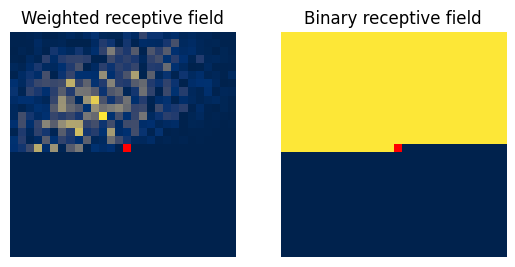

In [9]:
test_model = PixelCNN(c_in=1, c_hidden=128, kernel_size=5, num_layers=8).to('cpu')      # adjust according to your model
inp = torch.zeros(1,1,28,28).to('cpu')                    # do not remove the 'cpu' here
inp.requires_grad_()
out = test_model(inp)
show_center_recep_field(inp, out.squeeze(dim=2))
del inp, out, test_model

## Model Training

In [10]:
model = PixelCNN(c_in=1, c_hidden=128, kernel_size=5, num_layers=8)       # adjust according to your model
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
epochs = 25

Num params: 3,971,328


Epoch 1/25, Train Loss: 1.5847, Val Loss: 1.2609
Epoch 2/25, Train Loss: 1.2143, Val Loss: 1.1919
Epoch 3/25, Train Loss: 1.1773, Val Loss: 1.1646
Epoch 4/25, Train Loss: 1.1560, Val Loss: 1.1484
Epoch 5/25, Train Loss: 1.1430, Val Loss: 1.1354


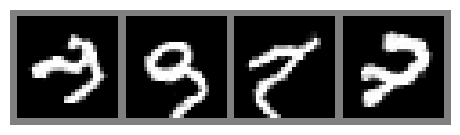

Epoch 6/25, Train Loss: 1.1298, Val Loss: 1.1297
Epoch 7/25, Train Loss: 1.1199, Val Loss: 1.1219
Epoch 8/25, Train Loss: 1.1147, Val Loss: 1.1104
Epoch 9/25, Train Loss: 1.1284, Val Loss: 1.1275
Epoch 10/25, Train Loss: 1.1102, Val Loss: 1.1073


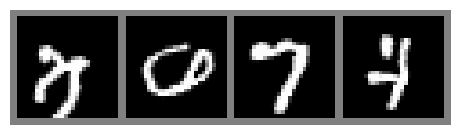

Epoch 11/25, Train Loss: 1.0994, Val Loss: 1.0940
Epoch 12/25, Train Loss: 1.0974, Val Loss: 1.0980
Epoch 13/25, Train Loss: 1.0881, Val Loss: 1.0861
Epoch 14/25, Train Loss: 1.0717, Val Loss: 1.0824
Epoch 15/25, Train Loss: 1.0698, Val Loss: 1.0701


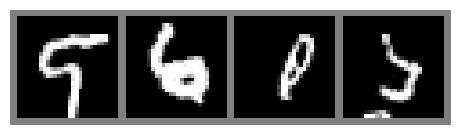

Epoch 16/25, Train Loss: 1.0573, Val Loss: 1.0620
Epoch 17/25, Train Loss: 1.0518, Val Loss: 1.0517
Epoch 18/25, Train Loss: 1.0464, Val Loss: 1.0499
Epoch 19/25, Train Loss: 1.0423, Val Loss: 1.0443
Epoch 20/25, Train Loss: 1.0343, Val Loss: 1.0398


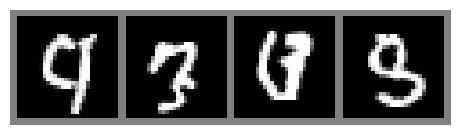

Epoch 21/25, Train Loss: 1.0282, Val Loss: 1.0346
Epoch 22/25, Train Loss: 1.0235, Val Loss: 1.0205
Epoch 23/25, Train Loss: 1.0185, Val Loss: 1.0166
Epoch 24/25, Train Loss: 1.0093, Val Loss: 1.0145
Epoch 25/25, Train Loss: 1.0052, Val Loss: 0.9999


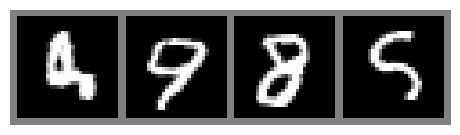

Test NLL: 0.9901


In [11]:
# Training loop
train_bpd = []
val_bpd = []

for epoch in range(epochs):
    model.train()
    losses = []

    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.calc_nll(imgs)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    train_bpd.append(np.mean(losses))
    scheduler.step()

    model.eval()
    losses = []
    with torch.no_grad():
      for imgs, _ in val_loader:
          imgs = imgs.to(device)
          loss = model.calc_nll(imgs)
          losses.append(loss.item())

    val_bpd.append(np.mean(losses))

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_bpd[-1]:.4f}, Val Loss: {val_bpd[-1]:.4f}")

    if (epoch + 1) % 5 == 0:
       sampled_images = model.sample(img_shape=(4, 1, 28, 28))
       show_imgs(sampled_images)

# Test loop
model.eval()
losses = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        loss = model.calc_nll(imgs)
        losses.append(loss.item())

test_bpd = np.mean(losses)
print(f"Test NLL: {test_bpd:.4f}")

## Question 1

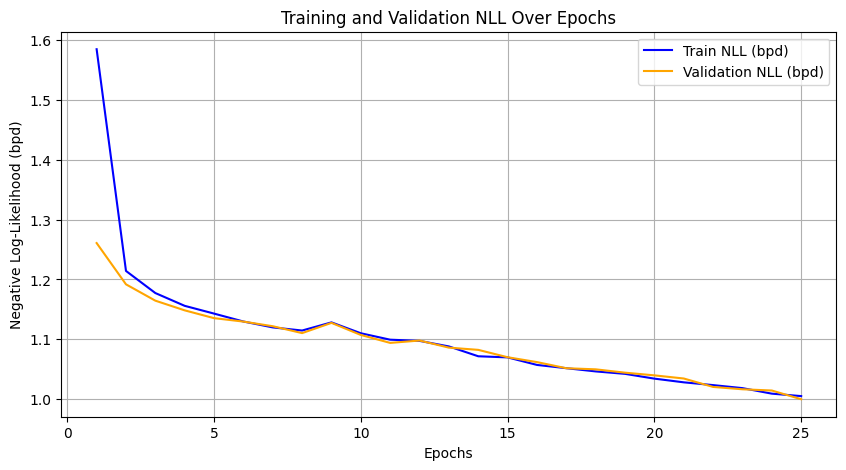

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_bpd, label='Train NLL (bpd)', color='blue')
plt.plot(range(1, epochs + 1), val_bpd, label='Validation NLL (bpd)', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Negative Log-Likelihood (bpd)')
plt.title('Training and Validation NLL Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
print("Final Training and Validation NLLs:")
for i, (t, v) in enumerate(zip(train_bpd, val_bpd)):
    print(f"Epoch {i+1}: Train BPD = {t:.4f}, Val BPD = {v:.4f}")

print(f"\nFinal Test BPD: {test_bpd:.4f}")

Final Training and Validation NLLs:
Epoch 1: Train BPD = 1.5847, Val BPD = 1.2609
Epoch 2: Train BPD = 1.2143, Val BPD = 1.1919
Epoch 3: Train BPD = 1.1773, Val BPD = 1.1646
Epoch 4: Train BPD = 1.1560, Val BPD = 1.1484
Epoch 5: Train BPD = 1.1430, Val BPD = 1.1354
Epoch 6: Train BPD = 1.1298, Val BPD = 1.1297
Epoch 7: Train BPD = 1.1199, Val BPD = 1.1219
Epoch 8: Train BPD = 1.1147, Val BPD = 1.1104
Epoch 9: Train BPD = 1.1284, Val BPD = 1.1275
Epoch 10: Train BPD = 1.1102, Val BPD = 1.1073
Epoch 11: Train BPD = 1.0994, Val BPD = 1.0940
Epoch 12: Train BPD = 1.0974, Val BPD = 1.0980
Epoch 13: Train BPD = 1.0881, Val BPD = 1.0861
Epoch 14: Train BPD = 1.0717, Val BPD = 1.0824
Epoch 15: Train BPD = 1.0698, Val BPD = 1.0701
Epoch 16: Train BPD = 1.0573, Val BPD = 1.0620
Epoch 17: Train BPD = 1.0518, Val BPD = 1.0517
Epoch 18: Train BPD = 1.0464, Val BPD = 1.0499
Epoch 19: Train BPD = 1.0423, Val BPD = 1.0443
Epoch 20: Train BPD = 1.0343, Val BPD = 1.0398
Epoch 21: Train BPD = 1.0282, Val

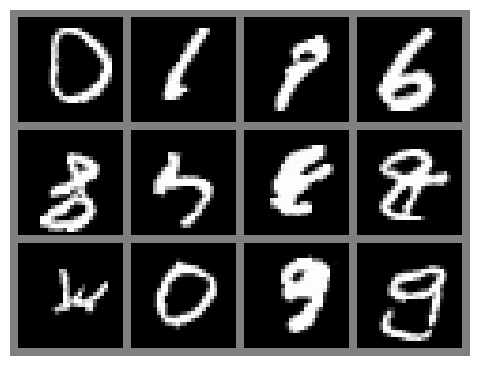

In [14]:
sampled_images = model.sample(img_shape=(12, 1, 28, 28))
show_imgs(sampled_images)

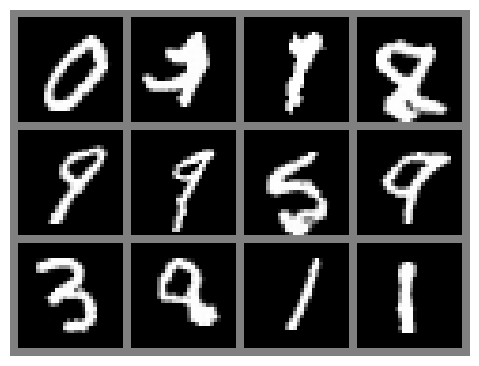

In [15]:
sampled_images = model.sample(img_shape=(12, 1, 28, 28))
show_imgs(sampled_images)

## Question 2

In [16]:
class NonCausalPixelwiseCNN(nn.Module):
    def __init__(self, c_in=1, c_hidden=128, num_layers=5):
        super().__init__()
        self.conv_in = nn.Conv2d(c_in, c_hidden, kernel_size=1)
        self.layers = nn.ModuleList([
            nn.Conv2d(c_hidden, c_hidden, kernel_size=1)
            for _ in range(num_layers)
        ])
        self.conv_out = nn.Conv2d(c_hidden, c_in * 256, kernel_size=1)

    def forward(self, x):
        x = (x.float() / 255.0) * 2 - 1
        h = F.relu(self.conv_in(x))
        for layer in self.layers:
            h = F.relu(layer(h))
        out = self.conv_out(h)
        out = out.reshape(out.shape[0], 256, out.shape[1]//256, out.shape[2], out.shape[3])
        return out

    def calc_nll(self, x):
        out = self(x)
        return F.cross_entropy(out, x) / math.log(2)
    
    @torch.no_grad()
    def sample(model, img_shape):
        dummy_img = torch.zeros(img_shape, dtype=torch.long).to(device)
        
        pred = model(dummy_img)
        
        B, Classes, C, H, W = pred.shape
        pred = pred.permute(0, 2, 3, 4, 1).reshape(-1, Classes)
        
        probs = F.softmax(pred, dim=-1)
        samples = torch.multinomial(probs, num_samples=1).squeeze(dim=-1)
        
        return samples.reshape(B, C, H, W)

non_causal_model = NonCausalPixelwiseCNN(c_in=1, c_hidden=128, num_layers=5).to(device)
optimizer_nc = optim.Adam(non_causal_model.parameters(), lr=1e-3)
scheduler_nc = optim.lr_scheduler.StepLR(optimizer_nc, 1, gamma=0.99)

In [17]:
nc_train_bpd = []
nc_val_bpd = []
epochs = 25

for epoch in range(epochs):
    non_causal_model.train()
    losses = []
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer_nc.zero_grad()
        loss = non_causal_model.calc_nll(imgs)
        loss.backward()
        optimizer_nc.step()
        losses.append(loss.item())

    nc_train_bpd.append(np.mean(losses))
    scheduler_nc.step()

    losses = []
    non_causal_model.eval()
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            loss = non_causal_model.calc_nll(imgs)
            losses.append(loss.item())

    nc_val_bpd.append(np.mean(losses))
    print(f"Epoch {epoch+1}/{epochs}, NC Train Loss: {nc_train_bpd[-1]:.4f}, NC Val Loss: {nc_val_bpd[-1]:.4f}")

# Test loop
non_causal_model.eval()
losses = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        loss = non_causal_model.calc_nll(imgs)
        losses.append(loss.item())

nc_test_bpd = np.mean(losses)
print(f"Test NLL: {nc_test_bpd:.4f}")

Epoch 1/25, NC Train Loss: 1.2710, NC Val Loss: 0.5845
Epoch 2/25, NC Train Loss: 0.6027, NC Val Loss: 0.6061
Epoch 3/25, NC Train Loss: 0.4184, NC Val Loss: 0.3251
Epoch 4/25, NC Train Loss: 0.5872, NC Val Loss: 0.3360
Epoch 5/25, NC Train Loss: 0.3115, NC Val Loss: 0.5723
Epoch 6/25, NC Train Loss: 0.3795, NC Val Loss: 1.2118
Epoch 7/25, NC Train Loss: 0.3354, NC Val Loss: 0.1988
Epoch 8/25, NC Train Loss: 0.2377, NC Val Loss: 0.1670
Epoch 9/25, NC Train Loss: 0.2441, NC Val Loss: 0.1936
Epoch 10/25, NC Train Loss: 0.1628, NC Val Loss: 0.1532
Epoch 11/25, NC Train Loss: 0.1200, NC Val Loss: 0.1119
Epoch 12/25, NC Train Loss: 0.4506, NC Val Loss: 0.2623
Epoch 13/25, NC Train Loss: 0.2238, NC Val Loss: 0.1940
Epoch 14/25, NC Train Loss: 0.1695, NC Val Loss: 0.1330
Epoch 15/25, NC Train Loss: 0.1452, NC Val Loss: 0.7050
Epoch 16/25, NC Train Loss: 0.1130, NC Val Loss: 0.0852
Epoch 17/25, NC Train Loss: 0.0759, NC Val Loss: 0.0705
Epoch 18/25, NC Train Loss: 0.0662, NC Val Loss: 0.0563
E

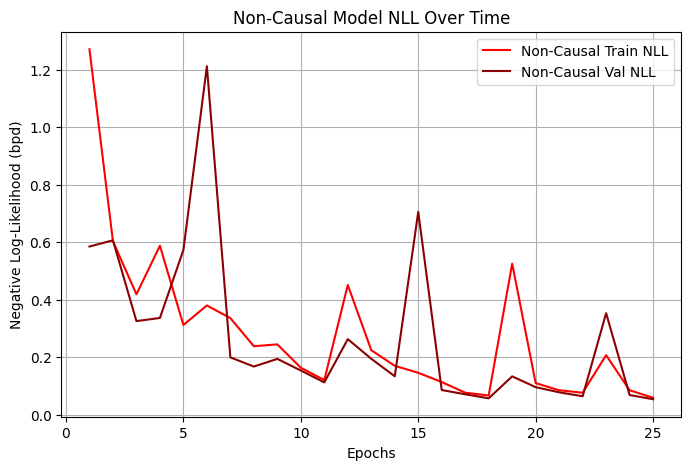

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), nc_train_bpd, label='Non-Causal Train NLL', color='red')
plt.plot(range(1, epochs + 1), nc_val_bpd, label='Non-Causal Val NLL', color='darkred')
plt.xlabel('Epochs')
plt.ylabel('Negative Log-Likelihood (bpd)')
plt.title('Non-Causal Model NLL Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
print("Final Training and Validation NLLs:")
for i, (t, v) in enumerate(zip(nc_train_bpd, nc_val_bpd)):
    print(f"Epoch {i+1}: Train BPD = {t:.4f}, Val BPD = {v:.4f}")

print(f"\nFinal Test BPD: {nc_test_bpd:.4f}")

Final Training and Validation NLLs:
Epoch 1: Train BPD = 1.2710, Val BPD = 0.5845
Epoch 2: Train BPD = 0.6027, Val BPD = 0.6061
Epoch 3: Train BPD = 0.4184, Val BPD = 0.3251
Epoch 4: Train BPD = 0.5872, Val BPD = 0.3360
Epoch 5: Train BPD = 0.3115, Val BPD = 0.5723
Epoch 6: Train BPD = 0.3795, Val BPD = 1.2118
Epoch 7: Train BPD = 0.3354, Val BPD = 0.1988
Epoch 8: Train BPD = 0.2377, Val BPD = 0.1670
Epoch 9: Train BPD = 0.2441, Val BPD = 0.1936
Epoch 10: Train BPD = 0.1628, Val BPD = 0.1532
Epoch 11: Train BPD = 0.1200, Val BPD = 0.1119
Epoch 12: Train BPD = 0.4506, Val BPD = 0.2623
Epoch 13: Train BPD = 0.2238, Val BPD = 0.1940
Epoch 14: Train BPD = 0.1695, Val BPD = 0.1330
Epoch 15: Train BPD = 0.1452, Val BPD = 0.7050
Epoch 16: Train BPD = 0.1130, Val BPD = 0.0852
Epoch 17: Train BPD = 0.0759, Val BPD = 0.0705
Epoch 18: Train BPD = 0.0662, Val BPD = 0.0563
Epoch 19: Train BPD = 0.5250, Val BPD = 0.1327
Epoch 20: Train BPD = 0.1092, Val BPD = 0.0952
Epoch 21: Train BPD = 0.0845, Val

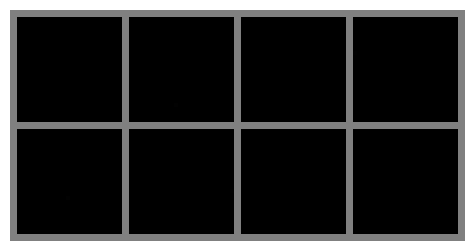

In [20]:
sampled_images_nc = non_causal_model.sample(img_shape=(8, 1, 28, 28))
show_imgs(sampled_images_nc)

## Question 3

In [22]:
# Use a real image from the val_loader
real_img, _ = next(iter(val_loader))
real_img = real_img[0:1].to(device)  # [1, 1, 28, 28]

<h3><font color='red'><b>a) Marginal probability of the first pixel (0,0) - easy</b></font></h3>

**Explanation:** The first pixel has no dependencies because PixelCNN predicts pixels sequentially starting from the top-left. Therefore, its marginal probability can be computed directly by passing a blank image (all pixels unknown) to the model and reading the predicted distribution at (0,0).

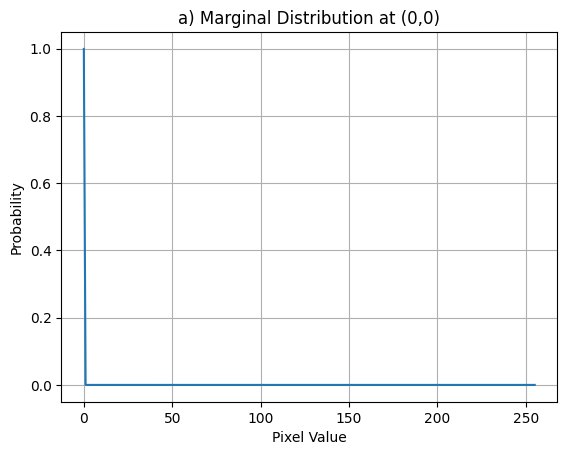

In [23]:
img = torch.zeros(1, 1, 28, 28).long().to(device) - 1
logits = model(img)
probs = F.softmax(logits[0,:,0,0,0], dim=0)

plt.figure()
# Add .detach() before .numpy()
plt.plot(probs.detach().cpu().numpy())
plt.title("a) Marginal Distribution at (0,0)")
plt.xlabel("Pixel Value")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

<h3><font color='red'><b>b) Marginal probability of the middle pixel (14,14) - hard</b></font></h3>

**Explanation:** The model predicts each pixel conditioned on the pixels before it. To compute the marginal distribution of the middle pixel, we would need to integrate over all possible configurations of the preceding pixels, which is intractable.  
**Approximation:** Use sampling: generate many full images using the model and collect the values at pixel (14,14) to empirically estimate the marginal distribution.

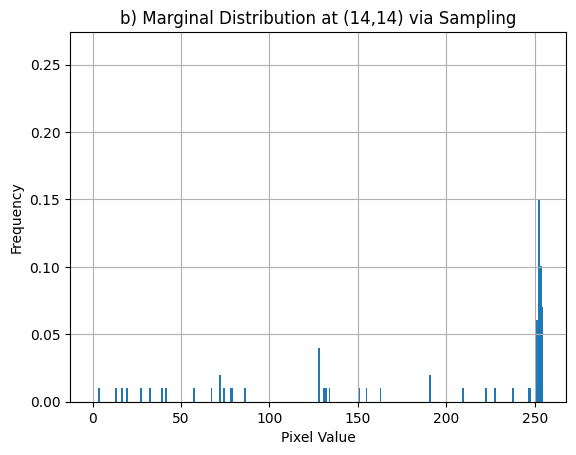

In [24]:
samples = [model.sample((1,1,28,28))[0,0,14,14].item() for _ in range(100)]

plt.figure()
plt.hist(samples, bins=256, range=(0,255), density=True)
plt.title("b) Marginal Distribution at (14,14) via Sampling")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

<h3><font color='red'><b>c) Conditional probability of the middle pixel (14,14), given all pixels above and to the left - easy</b></font></h3>

**Explanation:** This is the standard usage of PixelCNN. The model is trained to predict each pixel based on the pixels above and to the left of it. To compute this conditional probability, we provide the values of all pixels above and to the left of (14,14) and ask the model for the output distribution at that location.

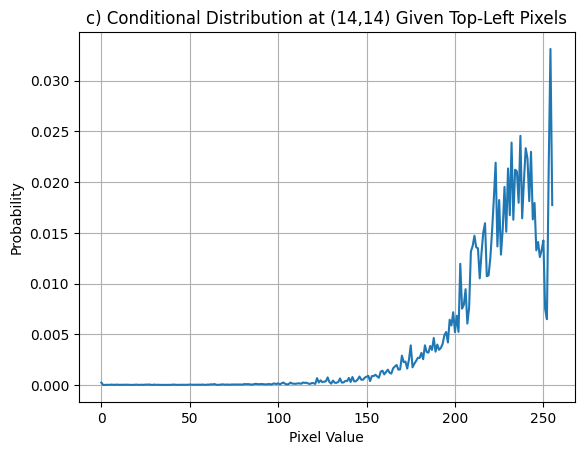

In [25]:
img = torch.zeros(1, 1, 28, 28).long().to(device) - 1
img[0,0,:14,:] = real_img[0,0,:14,:]
img[0,0,14,:14] = real_img[0,0,14,:14]
logits = model(img)
probs = F.softmax(logits[0,:,0,14,14], dim=0)

plt.figure()
plt.plot(probs.detach().cpu().numpy())
plt.title("c) Conditional Distribution at (14,14) Given Top-Left Pixels")
plt.xlabel("Pixel Value")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

<h3><font color='red'><b>d) Conditional probability of the middle pixel, given pixels below and to the right</b></font></h3>

**Explanation:** This is hard because PixelCNN is a causal model and only conditions on past pixels (above and to the left). It cannot directly compute this conditional.

**Approximation:** We approximate it using iterative resampling. We fix the pixels below and to the right of (14,14) from a real image, and repeatedly sample the value at (14,14), leaving all other pixels unknown. Although the model does not "see" the future pixels directly, this method can give an empirical distribution by resampling, similar to pseudo-Gibbs sampling.

d) Approximating conditional at (14,14) given bottom-right pixels using iterative sampling...


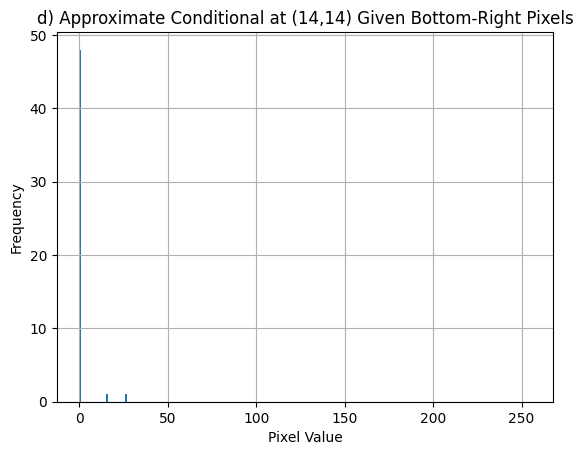

In [26]:
print("d) Approximating conditional at (14,14) given bottom-right pixels using iterative sampling...")

pixel_vals = []
for _ in range(50):
    img = torch.zeros(1, 1, 28, 28).long().to(device) - 1

    # Keep the pixels below and to the right of (14,14) fixed from a real image
    img[0, 0, 15:, :] = real_img[0, 0, 15:, :]
    img[0, 0, 14, 15:] = real_img[0, 0, 14, 15:]

    # Leave (14,14) as -1, and sample it while keeping other pixels fixed
    with torch.no_grad():
        out = model(img)
        probs = F.softmax(out[0, :, 0, 14, 14], dim=0)
        sample = torch.multinomial(probs, 1)
        pixel_vals.append(sample.item())

# Plot the histogram of samples
plt.figure()
plt.hist(pixel_vals, bins=256, range=(0, 255))
plt.title("d) Approximate Conditional at (14,14) Given Bottom-Right Pixels")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

<h3><font color='red'><b>e) Conditional probability of the middle pixel, given all other pixels in the image - hard</b></font></h3>

**Explanation:** This requires conditioning on both past and future pixels. Since PixelCNN only uses the past (i.e., top and left pixels), it cannot directly compute this.  
**Approximation:** We can approximate this using resampling. Fix all other pixels and repeatedly resample the center pixel (14,14) using the model, effectively approximating the distribution conditioned on the rest.


e) Approximating conditional at (14,14) given all others...


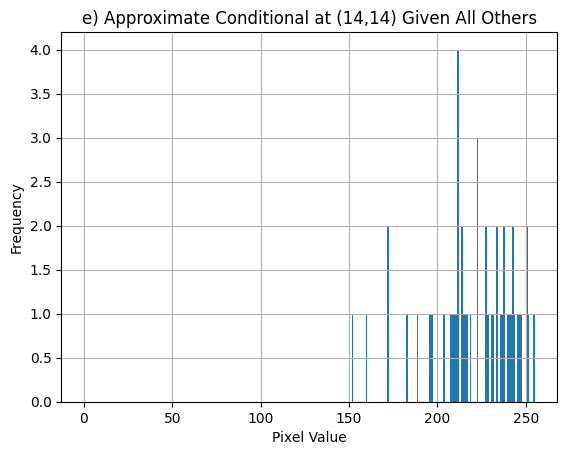

In [27]:
print("e) Approximating conditional at (14,14) given all others...")
pixel_vals = []
for _ in range(50):
    test_img = real_img.clone()
    test_img[0,0,14,14] = -1
    pred = model(test_img)
    p = F.softmax(pred[0,:,0,14,14], dim=0)
    sample = torch.multinomial(p, 1)
    pixel_vals.append(sample.item())

plt.figure()
plt.hist(pixel_vals, bins=256, range=(0,255))
plt.title("e) Approximate Conditional at (14,14) Given All Others")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

<h3><font color='red'><b>f) Samples of the bottom half of an image, given the top half - easy</b></font></h3>

**Explanation:** This is directly supported by the model. Since PixelCNN generates images from top-left to bottom-right, we can fix the top half and allow the model to generate the bottom half pixel-by-pixel, in raster scan order.

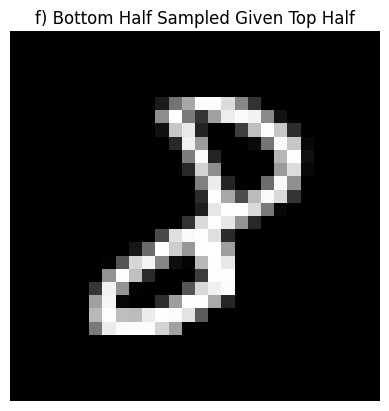

In [28]:
img = torch.zeros(1, 1, 28, 28).long().to(device) - 1
img[0,0,:14,:] = real_img[0,0,:14,:]
sampled = model.sample((1,1,28,28), img)

plt.figure()
plt.imshow(sampled[0,0].cpu().numpy(), cmap='gray')
plt.title("f) Bottom Half Sampled Given Top Half")
plt.axis('off')
plt.show()

<h3><font color='red'><b>g) Samples of the top half of an image, given the bottom half - hard</b></font></h3>

**Explanation:** The model cannot condition on future pixels (bottom half), so direct sampling is not possible.  
**Approximation:** Use an iterative method such as pseudo-Gibbs sampling. Fix the bottom half, initialize the top half randomly, and then sample each top-half pixel one at a time while keeping others fixed, gradually improving consistency.

g) Approximating top half given bottom half using iterative sampling...


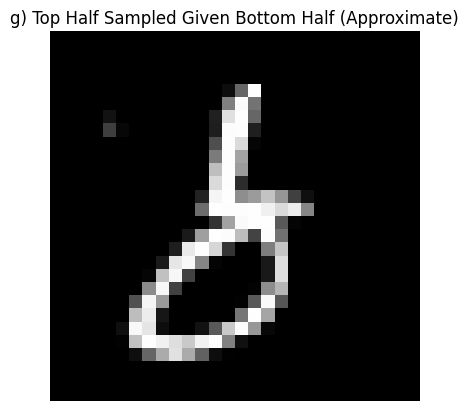

In [29]:
print("g) Approximating top half given bottom half using iterative sampling...")

# Use a real image to fill in the bottom half
img = torch.zeros(1, 1, 28, 28).long().to(device) - 1
img[0, 0, 14:, :] = real_img[0, 0, 14:, :]

# Iteratively sample the top half pixel by pixel (approximate Gibbs sampling)
for h in range(14):  # top half rows only
    for w in range(28):
        with torch.no_grad():
            pred = model(img)
            probs = F.softmax(pred[0,:,0,h,w], dim=0)
            sampled_val = torch.multinomial(probs, 1)
            img[0,0,h,w] = sampled_val.item()

# Show final result
plt.figure()
plt.imshow(img[0, 0].cpu().numpy(), cmap="gray")
plt.title("g) Top Half Sampled Given Bottom Half (Approximate)")
plt.axis("off")
plt.show()